In [46]:
from pandas import read_csv
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

# Importando dados

Nesse problema de predição, usaremos um dataset público do github. Assim, usamos a função read_csv do pandas passando uma URL como caminho dos dados.
* Usaremos os últimos 20% dos pontos temporais como dados de teste

* Uma transformação Min-Max é usada apenas para colocar os dados numa escala [0,1]

In [47]:
def get_train_test(url, split_percent=0.8):
    df = read_csv(url, usecols=['Open'], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()
    n = len(data)
    # Point for splitting data into train and test
    split = int(n*split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

sunspots_url = '/content/tesla_stock_2015_2022 (1).csv'  # must match uploaded file name
train_data, test_data, data = get_train_test(sunspots_url)

print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")

Train size: 1315, Test size: 329


# Preparação dos dados

Para preparar os dados para a rede recorrente, devemos quebrar a série temporal em vetores de tamanho igual ao número de entradas da nossa rede (estamos considerando assim quantos time steps passados estamos usando para prever o time step atual)

In [48]:
# Prepare the input X and target Y
def get_XY(dat, time_steps):
    # Indices of target array
    Y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[Y_ind]
    # Prepare X
    rows_x = len(Y)
    X = dat[range(time_steps*rows_x)]
    X = np.reshape(X, (rows_x, time_steps, 1))
    return X, Y

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

# Experimento 1: Construindo o modelo mais simples, com uma unica camada

Iniciaremos com uma única camada LSTM, mas com 50 unidades ocultas

In [49]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(LSTM(hidden_units, input_shape=input_shape,
                   activation=activation[0]))
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model
K.clear_session()
del model
model = create_RNN(hidden_units=50, dense_units=1, input_shape=(time_steps,1),
                   activation=['tanh', 'tanh'])
model.fit(trainX, trainY, validation_data=(testX, testY), epochs=20, batch_size=1, verbose=2)
model.summary()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


109/109 - 2s - 15ms/step - loss: 4.8170e-04 - val_loss: 0.0046
Epoch 2/20
109/109 - 0s - 4ms/step - loss: 7.7765e-05 - val_loss: 0.0060
Epoch 3/20
109/109 - 0s - 4ms/step - loss: 6.0502e-05 - val_loss: 0.0108
Epoch 4/20
109/109 - 1s - 6ms/step - loss: 9.0639e-05 - val_loss: 0.0148
Epoch 5/20
109/109 - 0s - 4ms/step - loss: 1.4275e-04 - val_loss: 0.0044
Epoch 6/20
109/109 - 0s - 4ms/step - loss: 5.7619e-05 - val_loss: 0.0092
Epoch 7/20
109/109 - 0s - 4ms/step - loss: 7.1391e-05 - val_loss: 0.0028
Epoch 8/20
109/109 - 0s - 4ms/step - loss: 5.8535e-05 - val_loss: 0.0025
Epoch 9/20
109/109 - 0s - 4ms/step - loss: 1.0277e-04 - val_loss: 0.0042
Epoch 10/20
109/109 - 1s - 6ms/step - loss: 8.5416e-05 - val_loss: 0.0030
Epoch 11/20
109/109 - 0s - 4ms/step - loss: 4.8814e-05 - val_loss: 0.0026
Epoch 12/20
109/109 - 1s - 6ms/step - loss: 6.1690e-05 - val_loss: 0.0023
Epoch 13/20
109/109 - 0s - 4ms/step - loss: 3.0928e-05 - val_loss: 0.0066
Epoch 14/20
109/109 - 0s - 4ms/step - loss: 5.4793e-05 - 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

## Avaliando o treinamento

Primeiro avaliamos o erro médio quadrático do conjunto de treino e de teste

In [50]:
def print_error(trainY, testY, train_predict, test_predict):
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    # Print RMSE
    print('Raíz do Erro Médio Quadrático para Treino: %.3f' % (train_rmse))
    print('Raíz do Erro Médio Quadrático para Teste: %.3f' % (test_rmse))

# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)
# Mean square error
print_error(trainY, testY, train_predict, test_predict)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Raíz do Erro Médio Quadrático para Treino: 0.006
Raíz do Erro Médio Quadrático para Teste: 0.048


Podemos também plotar como as nossas previsões se comparam com a série temporal original, como mostrado abaixo

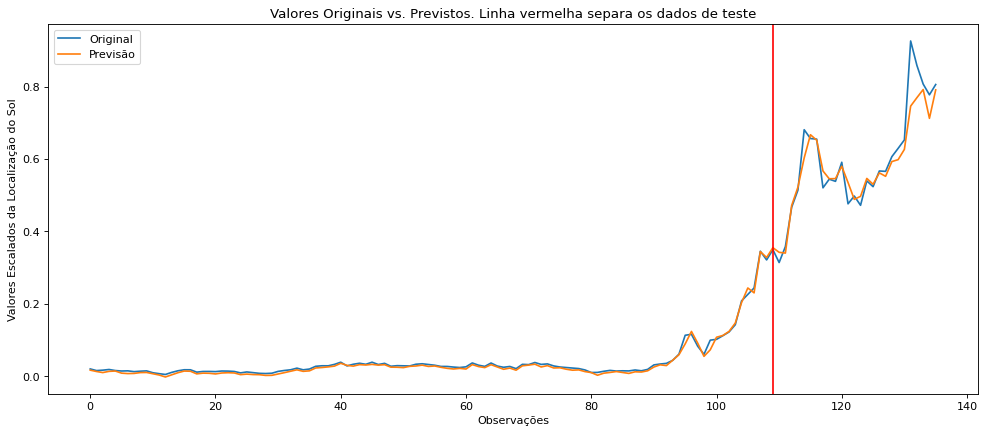

In [51]:
# Plot the result
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Original', 'Previsão'])
    plt.xlabel('Observações')
    plt.ylabel('Valores Escalados da Localização do Sol')
    plt.title('Valores Originais vs. Previstos. Linha vermelha separa os dados de teste')
plot_result(trainY, testY, train_predict, test_predict)

# Adicionando mais uma camada de LSTM


In [52]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(LSTM(hidden_units, input_shape=input_shape,return_sequences=True,
                   activation=activation[0]))
    model.add(LSTM(hidden_units, input_shape=input_shape, return_sequences=False,
                   activation=activation[0]))
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model
K.clear_session()
del model
model = create_RNN(hidden_units=50, dense_units=1, input_shape=(time_steps,1),
                   activation=['tanh', 'tanh'])
model.fit(trainX, trainY, validation_data=(testX, testY), epochs=20, batch_size=1, verbose=2)
model.summary()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


109/109 - 2s - 20ms/step - loss: 0.0017 - val_loss: 0.0033
Epoch 2/20
109/109 - 1s - 6ms/step - loss: 1.5467e-04 - val_loss: 0.0068
Epoch 3/20
109/109 - 1s - 6ms/step - loss: 2.5273e-04 - val_loss: 0.0183
Epoch 4/20
109/109 - 1s - 13ms/step - loss: 1.0591e-04 - val_loss: 0.0031
Epoch 5/20
109/109 - 1s - 12ms/step - loss: 1.6116e-04 - val_loss: 0.0031
Epoch 6/20
109/109 - 1s - 10ms/step - loss: 1.7102e-04 - val_loss: 0.0102
Epoch 7/20
109/109 - 1s - 6ms/step - loss: 1.7285e-04 - val_loss: 0.0029
Epoch 8/20
109/109 - 1s - 11ms/step - loss: 1.4443e-04 - val_loss: 0.0230
Epoch 9/20
109/109 - 1s - 6ms/step - loss: 2.6410e-04 - val_loss: 0.0115
Epoch 10/20
109/109 - 1s - 13ms/step - loss: 3.9580e-04 - val_loss: 0.0080
Epoch 11/20
109/109 - 1s - 6ms/step - loss: 1.1004e-04 - val_loss: 0.0064
Epoch 12/20
109/109 - 1s - 6ms/step - loss: 1.0511e-04 - val_loss: 0.0050
Epoch 13/20
109/109 - 1s - 11ms/step - loss: 1.0900e-04 - val_loss: 0.0048
Epoch 14/20
109/109 - 1s - 6ms/step - loss: 9.2201e-05 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

In [53]:
def print_error(trainY, testY, train_predict, test_predict):
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    # Print RMSE
    print('Raíz do Erro Médio Quadrático para Treino: %.3f' % (train_rmse))
    print('Raíz do Erro Médio Quadrático para Teste: %.3f' % (test_rmse))

# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)
# Mean square error
print_error(trainY, testY, train_predict, test_predict)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Raíz do Erro Médio Quadrático para Treino: 0.007
Raíz do Erro Médio Quadrático para Teste: 0.053


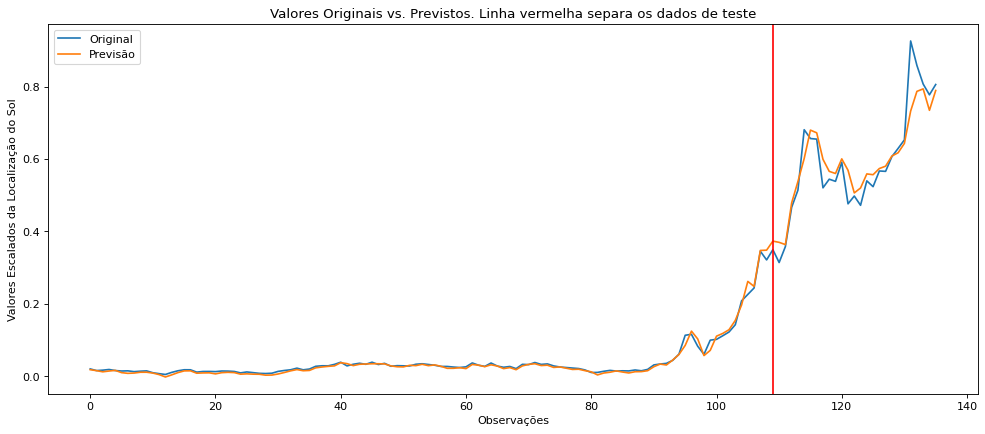

In [54]:
# Plot the result
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Original', 'Previsão'])
    plt.xlabel('Observações')
    plt.ylabel('Valores Escalados da Localização do Sol')
    plt.title('Valores Originais vs. Previstos. Linha vermelha separa os dados de teste')
plot_result(trainY, testY, train_predict, test_predict)

# Adicionando um Dropout de 20% após cada LSTM

In [55]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(LSTM(hidden_units, input_shape=input_shape,return_sequences=True,
                   activation=activation[0]))
    model.add(Dropout(0.2))  # Dropout 20% após a primeira LSTM
    model.add(LSTM(hidden_units, input_shape=input_shape, return_sequences=False,
                   activation=activation[0]))
    model.add(Dropout(0.2))  # Dropout 20% após a segunda LSTM
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model
K.clear_session()
del model
model = create_RNN(hidden_units=50, dense_units=1, input_shape=(time_steps,1),
                   activation=['tanh', 'tanh'])
model.fit(trainX, trainY, validation_data=(testX, testY), epochs=20, batch_size=1, verbose=2)
model.summary()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


109/109 - 3s - 29ms/step - loss: 8.3817e-04 - val_loss: 0.0367
Epoch 2/20
109/109 - 1s - 8ms/step - loss: 3.8570e-04 - val_loss: 0.0235
Epoch 3/20
109/109 - 1s - 10ms/step - loss: 3.9091e-04 - val_loss: 0.0034
Epoch 4/20
109/109 - 1s - 7ms/step - loss: 1.8083e-04 - val_loss: 0.0037
Epoch 5/20
109/109 - 1s - 6ms/step - loss: 2.2694e-04 - val_loss: 0.0162
Epoch 6/20
109/109 - 1s - 6ms/step - loss: 1.7028e-04 - val_loss: 0.0130
Epoch 7/20
109/109 - 1s - 6ms/step - loss: 8.3120e-05 - val_loss: 0.0078
Epoch 8/20
109/109 - 1s - 6ms/step - loss: 1.2300e-04 - val_loss: 0.0032
Epoch 9/20
109/109 - 1s - 6ms/step - loss: 5.0971e-04 - val_loss: 0.0627
Epoch 10/20
109/109 - 1s - 7ms/step - loss: 8.5768e-04 - val_loss: 0.0174
Epoch 11/20
109/109 - 1s - 7ms/step - loss: 1.3753e-04 - val_loss: 0.0042
Epoch 12/20
109/109 - 1s - 11ms/step - loss: 4.4915e-04 - val_loss: 0.0123
Epoch 13/20
109/109 - 1s - 12ms/step - loss: 1.7033e-04 - val_loss: 0.0121
Epoch 14/20
109/109 - 1s - 13ms/step - loss: 2.5987e-0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

In [56]:
def print_error(trainY, testY, train_predict, test_predict):
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    # Print RMSE
    print('Raíz do Erro Médio Quadrático para Treino: %.3f' % (train_rmse))
    print('Raíz do Erro Médio Quadrático para Teste: %.3f' % (test_rmse))

# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)
# Mean square error
print_error(trainY, testY, train_predict, test_predict)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Raíz do Erro Médio Quadrático para Treino: 0.010
Raíz do Erro Médio Quadrático para Teste: 0.053


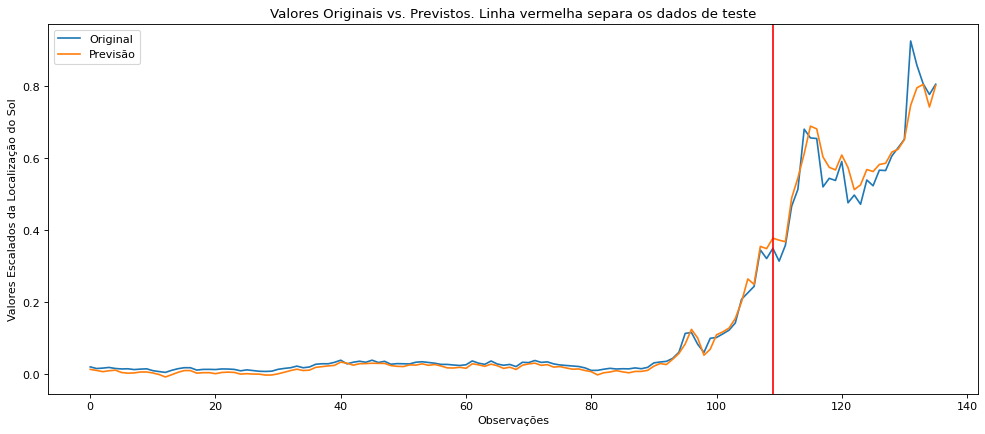

In [57]:
# Plot the result
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Original', 'Previsão'])
    plt.xlabel('Observações')
    plt.ylabel('Valores Escalados da Localização do Sol')
    plt.title('Valores Originais vs. Previstos. Linha vermelha separa os dados de teste')
plot_result(trainY, testY, train_predict, test_predict)

#  Teste com 4 blocos LSTM (50 unidades ocultas) + Dropout (20 %) antes da camada Dense

In [58]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(LSTM(hidden_units, input_shape=input_shape,return_sequences=True,
                   activation=activation[0]))
    model.add(LSTM(hidden_units, input_shape=input_shape,return_sequences=True,
                   activation=activation[0]))
    model.add(LSTM(hidden_units, input_shape=input_shape,return_sequences=True,
                   activation=activation[0]))
    model.add(LSTM(hidden_units, input_shape=input_shape, return_sequences=False,
                   activation=activation[0]))
    model.add(Dropout(0.2))  # Dropout 20% antes da camada Dense
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model
K.clear_session()
del model
model = create_RNN(hidden_units=50, dense_units=1, input_shape=(time_steps,1),
                   activation=['tanh', 'tanh'])
model.fit(trainX, trainY, validation_data=(testX, testY), epochs=20, batch_size=1, verbose=2)
model.summary()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


109/109 - 4s - 35ms/step - loss: 0.0027 - val_loss: 0.0436
Epoch 2/20
109/109 - 2s - 22ms/step - loss: 0.0014 - val_loss: 0.1189
Epoch 3/20
109/109 - 1s - 10ms/step - loss: 8.1835e-04 - val_loss: 0.0053
Epoch 4/20
109/109 - 1s - 11ms/step - loss: 3.9577e-04 - val_loss: 0.0850
Epoch 5/20
109/109 - 1s - 12ms/step - loss: 7.5757e-04 - val_loss: 0.0073
Epoch 6/20
109/109 - 1s - 11ms/step - loss: 3.4679e-04 - val_loss: 0.0321
Epoch 7/20
109/109 - 1s - 9ms/step - loss: 0.0011 - val_loss: 0.0042
Epoch 8/20
109/109 - 1s - 12ms/step - loss: 4.4217e-04 - val_loss: 0.0127
Epoch 9/20
109/109 - 1s - 11ms/step - loss: 2.2486e-04 - val_loss: 0.0052
Epoch 10/20
109/109 - 1s - 12ms/step - loss: 5.3882e-04 - val_loss: 0.0093
Epoch 11/20
109/109 - 2s - 16ms/step - loss: 2.0199e-04 - val_loss: 0.0055
Epoch 12/20
109/109 - 1s - 9ms/step - loss: 4.5593e-04 - val_loss: 0.0412
Epoch 13/20
109/109 - 1s - 8ms/step - loss: 5.6299e-04 - val_loss: 0.0218
Epoch 14/20
109/109 - 1s - 9ms/step - loss: 2.1716e-04 - val

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 213,155 (832.64 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 142,104 (555.10 KB)

In [59]:
def print_error(trainY, testY, train_predict, test_predict):
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    # Print RMSE
    print('Raíz do Erro Médio Quadrático para Treino: %.3f' % (train_rmse))
    print('Raíz do Erro Médio Quadrático para Teste: %.3f' % (test_rmse))

# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)
# Mean square error
print_error(trainY, testY, train_predict, test_predict)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Raíz do Erro Médio Quadrático para Treino: 0.013
Raíz do Erro Médio Quadrático para Teste: 0.146


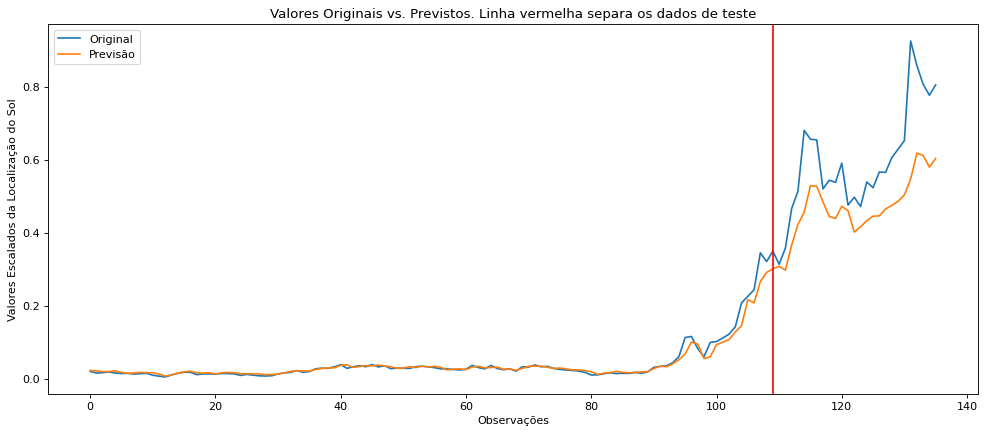

In [60]:
# Plot the result
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Original', 'Previsão'])
    plt.xlabel('Observações')
    plt.ylabel('Valores Escalados da Localização do Sol')
    plt.title('Valores Originais vs. Previstos. Linha vermelha separa os dados de teste')
plot_result(trainY, testY, train_predict, test_predict)

# Análise dos resultados
Experimento 1 foi o mais equilibrado: baixo erro em treino e teste, sugerindo que a arquitetura simples capturou bem os padrões sem sobreajustar.

Experimento 2 aumentou a capacidade do modelo, mas não trouxe ganho — possivelmente por falta de dados suficientes para treinar mais parâmetros.

Experimento 3 mostrou que o dropout foi agressivo demais para esse cenário, prejudicando a performance no teste.

Experimento 4 exagerou na complexidade e regularização, levando a um modelo que não aprendeu bem os padrões (underfitting).

Para este conjunto de dados, menos foi mais. O modelo inicial (1 camada LSTM de 50 unidades) foi o que melhor generalizou. Aumentar profundidade e aplicar dropout só fez sentido se houvesse mais dados ou ajustes finos na taxa de dropout e no número de unidades.